In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [141]:
stocks = {
    # Banking
    "HDFCBANK.NS": "Banking",
    "ICICIBANK.NS": "Banking",
    "SBIN.NS": "Banking",
    # IT
    "TCS.NS": "IT",
    "INFY.NS": "IT",
    "WIPRO.NS": "IT",
    # FMCG
    "HINDUNILVR.NS": "FMCG",
    "ITC.NS": "FMCG",
    "NESTLEIND.NS": "FMCG",
    # Auto
    "MARUTI.NS": "Auto",
    "EICHERMOT.NS": "Auto",
    "M&M.NS": "Auto",
    # Pharma
    "SUNPHARMA.NS": "Pharma",
    "CIPLA.NS": "Pharma",
    "DRREDDY.NS": "Pharma",
}
benchmark = "^NSEI"  # Nifty 50 index

In [142]:
tickers = list(stocks.keys()) + [benchmark]

price_data = {}

for ticker in tickers:
    print(f"Downloading {ticker}...")
    
    df = yf.download(
        ticker,
        start="2021-01-01",
        end="2026-01-01",
        auto_adjust=False,
        progress=False
    )
    
    # Check if download failed
    if df.empty:
        print(f"⚠️ No data found for {ticker} - skipping")
        continue
    
    # Get Close price
    close = df["Close"]
    
    # Convert to Series if needed
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    
    price_data[ticker] = close

# Combine everything
prices = pd.concat(price_data, axis=1)

print("\nFinal shape:", prices.shape)
prices.head()



Final shape: (1236, 16)


,HDFCBANK.NS,ICICIBANK.NS,SBIN.NS,TCS.NS,INFY.NS,WIPRO.NS,HINDUNILVR.NS,ITC.NS,NESTLEIND.NS,MARUTI.NS,EICHERMOT.NS,M&M.NS,SUNPHARMA.NS,CIPLA.NS,DRREDDY.NS,^NSEI
Date,,,,,,,,,,,,,,,,
2021-01-01,712.525024,527.500000,279.399994,2928.250000,1260.449951,194.050003,2387.550049,205.919418,922.534973,7691.299805,2542.699951,732.450012,596.250000,826.599976,1048.270020,14018.500000
2021-01-04,708.000000,531.700012,281.049988,3039.449951,1288.250000,198.199997,2426.500000,205.486115,918.897522,7702.299805,2655.699951,749.099976,604.400024,832.250000,1054.449951,14132.900391
2021-01-05,713.349976,537.250000,281.750000,3093.000000,1293.800049,203.149994,2450.550049,203.608429,927.912476,7655.450195,2674.899902,740.099976,603.450012,827.250000,1057.380005,14199.500000
2021-01-06,710.275024,546.700012,285.049988,3051.500000,1282.099976,203.199997,2417.300049,197.782791,925.762512,7628.600098,2645.350098,736.099976,605.299988,824.799988,1057.660034,14146.250000
2021-01-07,708.125000,541.099976,287.700012,3032.800049,1262.150024,203.375000,2368.850098,195.279205,906.364990,7566.049805,2649.800049,744.400024,601.900024,826.549988,1054.180054,14137.349609


## Cleaning the data

In [144]:
prices.isna().sum()

HDFCBANK.NS      0
ICICIBANK.NS     0
SBIN.NS          0
TCS.NS           0
INFY.NS          0
WIPRO.NS         0
HINDUNILVR.NS    0
ITC.NS           0
NESTLEIND.NS     0
MARUTI.NS        0
EICHERMOT.NS     0
M&M.NS           0
SUNPHARMA.NS     0
CIPLA.NS         0
DRREDDY.NS       0
^NSEI            0
dtype: int64

In [145]:
threshold = 0.05*len(prices)
prices_clean = prices.dropna(axis=1,thresh=len(prices) - threshold)

prices_clean = prices_clean.ffill()
print(prices_clean.shape)

(1236, 16)


### Saving it to excel

In [146]:
prices_clean.to_csv(r'C:\Users\saisu\Desktop\Project\prices_clean.csv')

### Connecting to a database

In [147]:
conn = sqlite3.connect("C:\\Users\\saisu\\Desktop\\Project\\portfolio.db")

In [148]:
price_data = pd.DataFrame(price_data)

In [149]:
price_data.to_sql('daily_prices',conn,if_exists = 'replace')

1236

### Creating a table to see which sector each stock belongs to

In [150]:
metadata = pd.DataFrame(
    [{"Ticker": t, "Sector": s} for t, s in stocks.items()]
)

In [151]:
metadata.to_sql('stock_meta',conn,if_exists='replace',index=False)

conn.commit()

### Viewing all the closing prices of FMCG stocks

In [152]:
# Check existing column names in the daily_prices table
pd.read_sql("PRAGMA table_info(daily_prices)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Date,TIMESTAMP,0,None,0
1,1,HDFCBANK.NS,REAL,0,None,0
2,2,ICICIBANK.NS,REAL,0,None,0
3,3,SBIN.NS,REAL,0,None,0
4,4,TCS.NS,REAL,0,None,0
5,5,INFY.NS,REAL,0,None,0
6,6,WIPRO.NS,REAL,0,None,0
7,7,HINDUNILVR.NS,REAL,0,None,0
8,8,ITC.NS,REAL,0,None,0
9,9,NESTLEIND.NS,REAL,0,None,0


In [153]:
query = """
SELECT Date, "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS"
FROM daily_prices
ORDER BY Date
"""

fmcg_prices = pd.read_sql(query, conn)
fmcg_prices.head()

,Date,HINDUNILVR.NS,ITC.NS,NESTLEIND.NS
0,2021-01-01 00:00:00,2387.550049,205.919418,922.534973
1,2021-01-04 00:00:00,2426.500000,205.486115,918.897522
2,2021-01-05 00:00:00,2450.550049,203.608429,927.912476
3,2021-01-06 00:00:00,2417.300049,197.782791,925.762512
4,2021-01-07 00:00:00,2368.850098,195.279205,906.364990


### Viewing all the closing prices of IT stocks

In [154]:
query = """
SELECT Date, "TCS.NS", "INFY.NS", "WIPRO.NS"
FROM daily_prices
ORDER BY Date
"""

it_prices = pd.read_sql(query, conn)
it_prices.head()

,Date,TCS.NS,INFY.NS,WIPRO.NS
0,2021-01-01 00:00:00,2928.250000,1260.449951,194.050003
1,2021-01-04 00:00:00,3039.449951,1288.250000,198.199997
2,2021-01-05 00:00:00,3093.000000,1293.800049,203.149994
3,2021-01-06 00:00:00,3051.500000,1282.099976,203.199997
4,2021-01-07 00:00:00,3032.800049,1262.150024,203.375000


### Recent 10 day trading IT stocks


In [155]:
query = """
SELECT Date, "TCS.NS", "INFY.NS", "WIPRO.NS"
FROM daily_prices
ORDER BY Date DESC
LIMIT 10
"""

IT_prices = pd.read_sql(query, conn)
IT_prices

,Date,TCS.NS,INFY.NS,WIPRO.NS
0,2025-12-31 00:00:00,3206.199951,1615.400024,263.279999
1,2025-12-30 00:00:00,3246.800049,1621.599976,263.649994
2,2025-12-29 00:00:00,3251.500000,1644.699951,264.239990
3,2025-12-26 00:00:00,3280.000000,1656.099976,266.299988
4,2025-12-24 00:00:00,3319.000000,1663.400024,268.059998
5,2025-12-23 00:00:00,3310.000000,1668.300049,271.399994
6,2025-12-22 00:00:00,3324.899902,1689.599976,272.670013
7,2025-12-19 00:00:00,3282.000000,1638.699951,264.450012
8,2025-12-18 00:00:00,3280.800049,1626.800049,263.850006
9,2025-12-17 00:00:00,3217.800049,1602.000000,261.140015


### Calculating Daily, Annual Returns and Volatility

In [157]:
daily_returns = prices.pct_change().dropna()
print(f'Daily returns:\n{daily_returns.head()}\n')

Daily returns:
            HDFCBANK.NS  ICICIBANK.NS   SBIN.NS    TCS.NS   INFY.NS  WIPRO.NS  \
Date                                                                            
2021-01-04    -0.006351      0.007962  0.005905  0.037975  0.022056  0.021386   
2021-01-05     0.007556      0.010438  0.002491  0.017618  0.004308  0.024975   
2021-01-06    -0.004311      0.017590  0.011712 -0.013417 -0.009043  0.000246   
2021-01-07    -0.003027     -0.010243  0.009297 -0.006128 -0.015560  0.000861   
2021-01-08     0.010874      0.001756 -0.005909  0.029049  0.039575  0.057652   

            HINDUNILVR.NS    ITC.NS  NESTLEIND.NS  MARUTI.NS  EICHERMOT.NS  \
Date                                                                         
2021-01-04       0.016314 -0.002104     -0.003943   0.001430      0.044441   
2021-01-05       0.009911 -0.009138      0.009811  -0.006083      0.007230   
2021-01-06      -0.013568 -0.028612     -0.002317  -0.003507     -0.011047   
2021-01-07      -0.020043 -

In [158]:
annualized_returns = daily_returns.mean() * 252
print(f'Annual Returns:\n{annualized_returns}')

Annual Returns:
HDFCBANK.NS      0.089984
ICICIBANK.NS     0.214920
SBIN.NS          0.291238
TCS.NS           0.040071
INFY.NS          0.079799
WIPRO.NS         0.095818
HINDUNILVR.NS    0.014058
ITC.NS           0.157567
NESTLEIND.NS     0.085474
MARUTI.NS        0.185283
EICHERMOT.NS     0.249149
M&M.NS           0.371573
SUNPHARMA.NS     0.238001
CIPLA.NS         0.149732
DRREDDY.NS       0.063225
^NSEI            0.136884
dtype: float64


In [159]:
annual_volatility = daily_returns.std() * np.sqrt(252)
print(f'Annual Volatility:\n{annual_volatility}')

Annual Volatility:
HDFCBANK.NS      0.212796
ICICIBANK.NS     0.220774
SBIN.NS          0.263102
TCS.NS           0.207875
INFY.NS          0.241407
WIPRO.NS         0.259272
HINDUNILVR.NS    0.201482
ITC.NS           0.202851
NESTLEIND.NS     0.186594
MARUTI.NS        0.233289
EICHERMOT.NS     0.259599
M&M.NS           0.284725
SUNPHARMA.NS     0.209319
CIPLA.NS         0.231248
DRREDDY.NS       0.217968
^NSEI            0.139877
dtype: float64


In [160]:
#Calculation of Sharpe Ratio
risk_free_rate = 0.06 # Assuming 6% risk-free rate

sharpe_ratios = (annualized_returns - risk_free_rate) / annual_volatility
print(f'Sharpe Ratios:\n{sharpe_ratios.sort_values(ascending=False)}')  

Sharpe Ratios:
M&M.NS           1.094294
SBIN.NS          0.878893
SUNPHARMA.NS     0.850381
EICHERMOT.NS     0.728620
ICICIBANK.NS     0.701713
^NSEI            0.549652
MARUTI.NS        0.537027
ITC.NS           0.480978
CIPLA.NS         0.388032
HDFCBANK.NS      0.140905
WIPRO.NS         0.138148
NESTLEIND.NS     0.136520
INFY.NS          0.082016
DRREDDY.NS       0.014796
TCS.NS          -0.095872
HINDUNILVR.NS   -0.228022
dtype: float64


From the above Sharpe Ratios, M$M leads the chart with the highest sharpe ratio (1.09).They provide the best risk adjusted return at 6% risk-free rate. SBI (0.87), SunPharma (0.85) and ICICI bank (0.70) have outperformed the market benchmark on risk adjusted basis. Nifty 50 is set as a baseline for the stocks at 0.55. Stocks below a sharpe ratio of 0.55 are likely to provide less return per unit of risk.

In [161]:
# Calculation of Beta (sensitivity to market movements)

benchmark = '^NSEI'  # Nifty 50 index
cov = daily_returns.cov()[benchmark]
benchmark_var = daily_returns[benchmark].var()

beta = cov / benchmark_var
print(f'Beta Values:\n{beta.sort_values(ascending=False).head(10)}')

Beta Values:
SBIN.NS         1.231073
M&M.NS          1.144979
ICICIBANK.NS    1.082284
HDFCBANK.NS     1.056509
WIPRO.NS        1.022690
^NSEI           1.000000
INFY.NS         0.957691
EICHERMOT.NS    0.952329
MARUTI.NS       0.814369
TCS.NS          0.785842
Name: ^NSEI, dtype: float64


From the above Beta values, SBI, M&M, ICICI, HDFC and Wipro and more volatile than the market. If Nifty 50 moves up or down by 1%, State Bank of India tends to move roughly 1.23% in the same direction. NSEI serves as the benchmark to understand the volatility of other stocks. Maruti, TCS and ITC are very defensive. If the market drops by 1%, ITC is expected to drop by only about 0.67%.

In [162]:
# Correlation Matrix
correlation_matrix = daily_returns.corr()
print(f'Correlation Matrix:\n{correlation_matrix}')

Correlation Matrix:
               HDFCBANK.NS  ICICIBANK.NS   SBIN.NS    TCS.NS   INFY.NS  \
HDFCBANK.NS       1.000000      0.531632  0.423681  0.229695  0.258390   
ICICIBANK.NS      0.531632      1.000000  0.558693  0.218879  0.264989   
SBIN.NS           0.423681      0.558693  1.000000  0.203273  0.194256   
TCS.NS            0.229695      0.218879  0.203273  1.000000  0.702128   
INFY.NS           0.258390      0.264989  0.194256  0.702128  1.000000   
WIPRO.NS          0.281847      0.257070  0.264632  0.605258  0.635917   
HINDUNILVR.NS     0.175820      0.140996  0.080494  0.241665  0.214834   
ITC.NS            0.226371      0.286886  0.333197  0.168533  0.178757   
NESTLEIND.NS      0.165226      0.167611  0.113934  0.228907  0.189857   
MARUTI.NS         0.279842      0.291780  0.317452  0.199173  0.183717   
EICHERMOT.NS      0.304084      0.328103  0.334866  0.203873  0.203657   
M&M.NS            0.330770      0.362330  0.364136  0.222109  0.262643   
SUNPHARMA.NS      

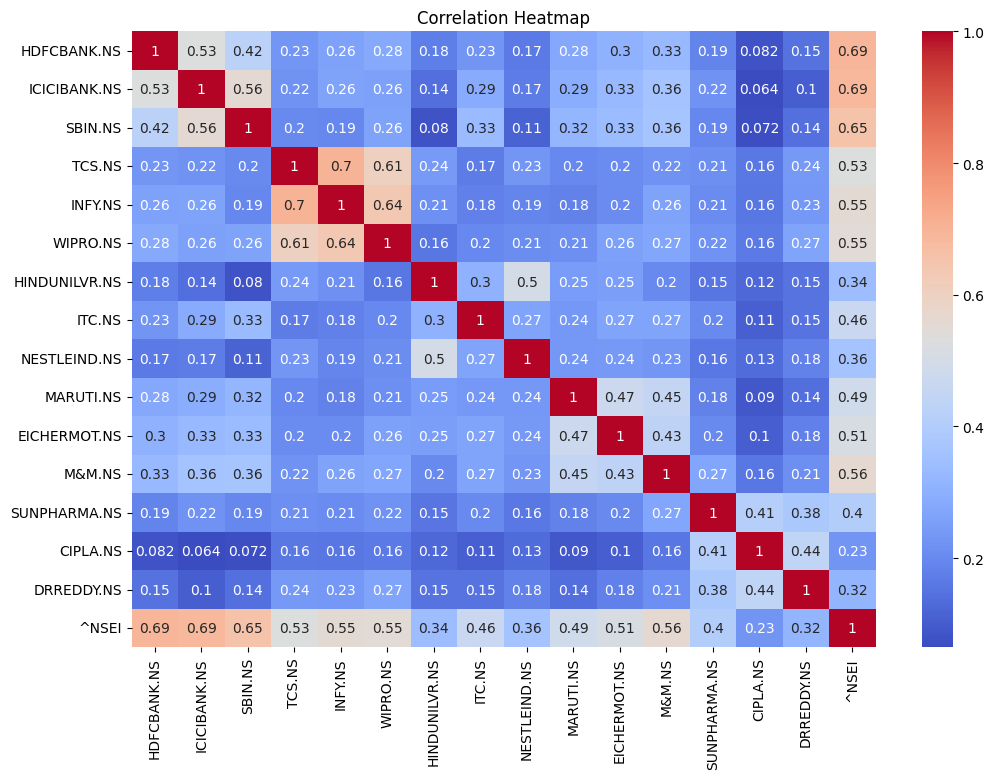

In [163]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap talks about the daily returns of all the stocks and Nifty 50 index. The IT stocks (TCS, Infosys, Wipro) exhibit the highest correlation on the map at 0.70. Holding multiple IT stocks provides minimal sector diversification. ICICI Bank shares a correlation of 0.56 with SBI, and 0.53 with HDFC Bank.

In [164]:
# 1. Combine your calculated metrics into a DataFrame
summary = pd.DataFrame({
    'Annual_Volatility': annual_volatility,
    'Sharpe_Ratio': sharpe_ratios,
    'Beta': beta
})

# 2. Save to SQLite database
summary.to_sql("stock_summary", conn, if_exists="replace")
conn.commit()
print("Summary saved to database")

Summary saved to database


In [165]:
summary.head()

,Annual_Volatility,Sharpe_Ratio,Beta
HDFCBANK.NS,0.212796,0.140905,1.056509
ICICIBANK.NS,0.220774,0.701713,1.082284
SBIN.NS,0.263102,0.878893,1.231073
TCS.NS,0.207875,-0.095872,0.785842
INFY.NS,0.241407,0.082016,0.957691


In [166]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                name
0  optimal_portfolio
1   backtest_results
2       daily_prices
3         stock_meta
4      stock_summary


In [167]:
result = pd.read_sql("SELECT * FROM daily_prices", conn)
print(result)

                     Date  HDFCBANK.NS  ICICIBANK.NS     SBIN.NS       TCS.NS  \
0     2021-01-01 00:00:00   712.525024    527.500000  279.399994  2928.250000   
1     2021-01-04 00:00:00   708.000000    531.700012  281.049988  3039.449951   
2     2021-01-05 00:00:00   713.349976    537.250000  281.750000  3093.000000   
3     2021-01-06 00:00:00   710.275024    546.700012  285.049988  3051.500000   
4     2021-01-07 00:00:00   708.125000    541.099976  287.700012  3032.800049   
...                   ...          ...           ...         ...          ...   
1231  2025-12-24 00:00:00   997.200012   1359.800049  968.950012  3319.000000   
1232  2025-12-26 00:00:00   992.099976   1350.400024  966.299988  3280.000000   
1233  2025-12-29 00:00:00   991.700012   1343.300049  965.049988  3251.500000   
1234  2025-12-30 00:00:00   990.900024   1342.500000  973.450012  3246.800049   
1235  2025-12-31 00:00:00   991.200012   1342.900024  982.200012  3206.199951   

          INFY.NS    WIPRO.

## Modern Portfolio Theory

In [168]:
# Create equal weights (1/14 for each asset)
num_assets = len(annualized_returns)
weights = np.ones(num_assets) / num_assets

# Calculate portfolio return
portfolio_returns = np.dot(annualized_returns, weights)
print(f'Portfolio expected return: {portfolio_returns * 100:.2f} %')

Portfolio expected return: 15.39 %


In [169]:
#Covariance matrix
cov_matrix = daily_returns.cov() * 252
print(f'Covariance Matrix:\n{cov_matrix}')

Covariance Matrix:
               HDFCBANK.NS  ICICIBANK.NS   SBIN.NS    TCS.NS   INFY.NS  \
HDFCBANK.NS       0.045282      0.024976  0.023721  0.010161  0.013274   
ICICIBANK.NS      0.024976      0.048741  0.032452  0.010045  0.014123   
SBIN.NS           0.023721      0.032452  0.069223  0.011117  0.012338   
TCS.NS            0.010161      0.010045  0.011117  0.043212  0.035235   
INFY.NS           0.013274      0.014123  0.012338  0.035235  0.058277   
WIPRO.NS          0.015550      0.014715  0.018052  0.032621  0.039802   
HINDUNILVR.NS     0.007538      0.006272  0.004267  0.010122  0.010449   
ITC.NS            0.009771      0.012848  0.017783  0.007107  0.008754   
NESTLEIND.NS      0.006561      0.006905  0.005593  0.008879  0.008552   
MARUTI.NS         0.013892      0.015028  0.019485  0.009659  0.010347   
EICHERMOT.NS      0.016798      0.018804  0.022872  0.011002  0.012763   
M&M.NS            0.020041      0.022776  0.027278  0.013146  0.018053   
SUNPHARMA.NS      0

In [170]:
portfolio_variance = weights @ cov_matrix.values @ weights
portfolio_volatility = portfolio_variance**0.5

print(f'Portfolio Variance: {portfolio_variance:.4f}')
print(f'Portfolio volatility (risk): {portfolio_volatility*100:.2f} %')

Portfolio Variance: 0.0158
Portfolio volatility (risk): 12.57 %


In [171]:
# Checking diversification benefits
individual_vols = np.sqrt(np.diag(cov_matrix.values))
no_diversification_risk = np.dot(weights,individual_vols)

print(f'Portfolio risk (with diversification):  {portfolio_volatility*100:.2f}%')
print(f'Risk if no diversification benefit:     {no_diversification_risk*100:.2f}%')
print(f'Diversification benefit:                {(no_diversification_risk-portfolio_volatility)*100:.2f}%')

Portfolio risk (with diversification):  12.57%
Risk if no diversification benefit:     22.33%
Diversification benefit:                9.76%


### Simulating 50000 portfolios

In [172]:
RF_rate = 0.06 #Assuming 6% risk-free rate

n_portfolios = 50000
np.random.seed(42)

num_assets = len(annualized_returns)

random_weights = np.random.dirichlet(np.ones(num_assets),n_portfolios)

port_returns = random_weights @ annualized_returns.values
# Calculate portfolio variances: shape (n_portfolios,)
port_vars = np.einsum('ij,jk,ik->i', random_weights, cov_matrix.values, random_weights)
port_risks = np.sqrt(port_vars)

# Sharpe ratio (removed the extra () on port_risks)
port_sharpes = (port_returns - RF_rate) / port_risks

In [173]:
# Find the index of the maximum Sharpe ratio and minimum risk portfolios
max_sharpe_idx = np.argmax(port_sharpes)
min_risk_idx = np.argmin(port_risks)

print("Max Sharpe portfolio:")
print(f"Weights: {dict(zip(tickers, random_weights[max_sharpe_idx].round(3)))}")
print(f"Return: {port_returns[max_sharpe_idx]*100:.2f}%  Risk: {port_risks[max_sharpe_idx]*100:.2f}%  Sharpe: {port_sharpes[max_sharpe_idx]:.3f}")

print("\nMin Risk (Minimum Variance) portfolio:")
print(f"Weights: {dict(zip(tickers, random_weights[min_risk_idx].round(3)))}")
print(f"Return: {port_returns[min_risk_idx]*100:.2f}%  Risk: {port_risks[min_risk_idx]*100:.2f}%")


Max Sharpe portfolio:
Weights: {'HDFCBANK.NS': np.float64(0.018), 'ICICIBANK.NS': np.float64(0.104), 'SBIN.NS': np.float64(0.069), 'TCS.NS': np.float64(0.019), 'INFY.NS': np.float64(0.009), 'WIPRO.NS': np.float64(0.007), 'HINDUNILVR.NS': np.float64(0.01), 'ITC.NS': np.float64(0.011), 'NESTLEIND.NS': np.float64(0.01), 'MARUTI.NS': np.float64(0.006), 'EICHERMOT.NS': np.float64(0.134), 'M&M.NS': np.float64(0.319), 'SUNPHARMA.NS': np.float64(0.218), 'CIPLA.NS': np.float64(0.035), 'DRREDDY.NS': np.float64(0.026), '^NSEI': np.float64(0.006)}
Return: 26.13%  Risk: 16.35%  Sharpe: 1.231

Min Risk (Minimum Variance) portfolio:
Weights: {'HDFCBANK.NS': np.float64(0.046), 'ICICIBANK.NS': np.float64(0.077), 'SBIN.NS': np.float64(0.021), 'TCS.NS': np.float64(0.063), 'INFY.NS': np.float64(0.013), 'WIPRO.NS': np.float64(0.001), 'HINDUNILVR.NS': np.float64(0.151), 'ITC.NS': np.float64(0.11), 'NESTLEIND.NS': np.float64(0.139), 'MARUTI.NS': np.float64(0.09), 'EICHERMOT.NS': np.float64(0.002), 'M&M.NS': 

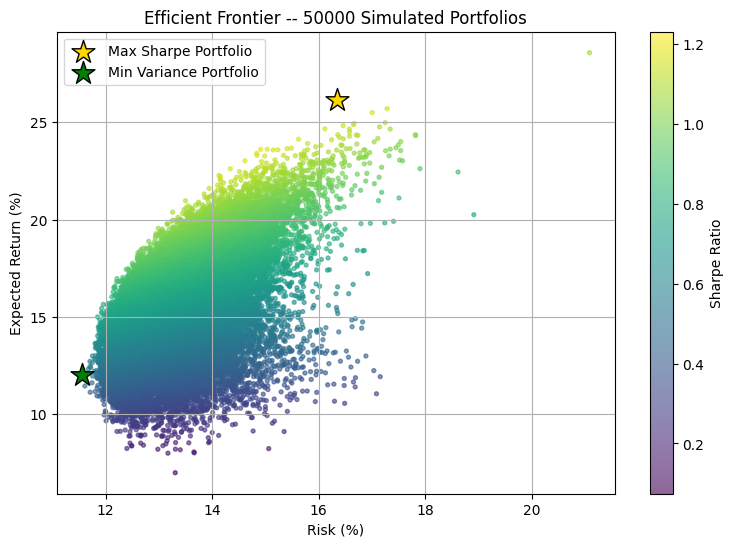

In [174]:
plt.figure(figsize=(9, 6))
plt.scatter(port_risks*100, port_returns*100, c=port_sharpes, cmap="viridis", s=8, alpha=0.6)
plt.colorbar(label="Sharpe Ratio")
plt.scatter(port_risks[max_sharpe_idx]*100, port_returns[max_sharpe_idx]*100,
            color="gold", marker="*", s=300, edgecolor="black", label="Max Sharpe Portfolio")
plt.scatter(port_risks[min_risk_idx]*100, port_returns[min_risk_idx]*100,
            color="green", marker="*", s=300, edgecolor="black", label="Min Variance Portfolio")
plt.xlabel("Risk (%)")
plt.ylabel("Expected Return (%)")
plt.title(f"Efficient Frontier -- {n_portfolios} Simulated Portfolios")
plt.legend()
plt.grid(True)
plt.show()

The above efficient frontier is simulated with 50,000 portfolio combinations. The X-axis represents the volatility(risk%) of each simulated portfolio, from 11% to 21%. The Y-axis represents the projected expected return(%). The colour bar shows the sharpe ratios ranging from 0.2 to 1.2. The boundary forming the upper-left edge represents the Efficient Frontier. The set of optimal portfolios offers the highest return for a given risk level. The yellow star represents the maximum sharpe ratio portfolio and the green star represents the minimum variance portfolio.

Portfolios lying below the upper boundary (e.g., risk of 15% with only 10% return) are sub-optimal because you can achieve higher returns (~22%) at that same level of risk simply by adjusting asset weights.


In [175]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                name
0  optimal_portfolio
1   backtest_results
2       daily_prices
3         stock_meta
4      stock_summary


## Backtesting

### To test whether the optimized portfolio would have actually worked, on data separate from what built it

In [205]:
#Splitting the data into training and testing sets
split_date = "2024-01-01"

test_returns = daily_returns[daily_returns.index >= split_date]
test_benchmark_returns = test_returns[benchmark]

stock_tickers = list(stocks.keys())
train_returns = daily_returns.loc[daily_returns.index < split_date, stock_tickers]

print(f'Training period returns:\n{train_returns.head()}\n')


Training period returns:
            HDFCBANK.NS  ICICIBANK.NS   SBIN.NS    TCS.NS   INFY.NS  WIPRO.NS  \
Date                                                                            
2021-01-04    -0.006351      0.007962  0.005905  0.037975  0.022056  0.021386   
2021-01-05     0.007556      0.010438  0.002491  0.017618  0.004308  0.024975   
2021-01-06    -0.004311      0.017590  0.011712 -0.013417 -0.009043  0.000246   
2021-01-07    -0.003027     -0.010243  0.009297 -0.006128 -0.015560  0.000861   
2021-01-08     0.010874      0.001756 -0.005909  0.029049  0.039575  0.057652   

            HINDUNILVR.NS    ITC.NS  NESTLEIND.NS  MARUTI.NS  EICHERMOT.NS  \
Date                                                                         
2021-01-04       0.016314 -0.002104     -0.003943   0.001430      0.044441   
2021-01-05       0.009911 -0.009138      0.009811  -0.006083      0.007230   
2021-01-06      -0.013568 -0.028612     -0.002317  -0.003507     -0.011047   
2021-01-07      -

In [206]:
train_annualized_returns = train_returns.mean() * 252
train_cov_matrix = train_returns.cov() * 252

In [207]:
#Re-run monte carlo simulation with training data
n_portfolios = 50000
np.random.seed(42)

num_assets = len(train_annualized_returns)

train_random_weights = np.random.dirichlet(np.ones(num_assets), n_portfolios)

train_port_returns = train_random_weights @ train_annualized_returns.values
train_port_vars = np.einsum('ij,jk,ik->i', train_random_weights, train_cov_matrix.values, train_random_weights)
train_port_risks = np.sqrt(train_port_vars)
train_port_sharpes = (train_port_returns - RF_rate) / train_port_risks



In [208]:
#Find optimal weights for max Sharpe ratio portfolio
train_max_sharpe_idx = np.argmax(train_port_sharpes)
optimal_weights = train_random_weights[train_max_sharpe_idx]

print(f'Training returns: {train_port_returns[train_max_sharpe_idx]*100:.2f}%')
print(f'Training risk: {train_port_risks[train_max_sharpe_idx]*100:.2f}%')
print(f'Training Sharpe ratio: {train_port_sharpes[train_max_sharpe_idx]:.4f}')

Training returns: 24.68%
Training risk: 14.17%
Training Sharpe ratio: 1.3185


In [209]:
test_returns_stocks_only = test_returns.drop(columns=[benchmark])
print(f'test_returns_stocks_only:\n{test_returns_stocks_only}\n')

test_returns_stocks_only:
            HDFCBANK.NS  ICICIBANK.NS   SBIN.NS    TCS.NS   INFY.NS  WIPRO.NS  \
Date                                                                            
2024-01-01    -0.006523      0.002810 -0.001090  0.004666  0.005477  0.012412   
2024-01-02     0.000589     -0.017160 -0.002962 -0.007321 -0.010926 -0.016661   
2024-01-03    -0.015420      0.001833  0.006255 -0.024173 -0.028936 -0.028346   
2024-01-04     0.010730      0.003150 -0.001088 -0.006758  0.015235 -0.007677   
2024-01-05    -0.005116      0.006635 -0.001245  0.019390  0.013122  0.009284   
...                 ...           ...       ...       ...       ...       ...   
2025-12-24     0.000602     -0.002348 -0.003035  0.002719 -0.002937 -0.012307   
2025-12-26    -0.005114     -0.006913 -0.002735 -0.011751 -0.004389 -0.006566   
2025-12-29    -0.000403     -0.005258 -0.001294 -0.008689 -0.006884 -0.007736   
2025-12-30    -0.000807     -0.000596  0.008704 -0.001445 -0.014045 -0.002233   
20

In [ ]:
#Applying the training-only optimal weights to the test period returns to calculate the portfolio returns
portfolio_test_returns = test_returns_stocks_only.dot(optimal_weights)
print(f'Portfolio test returns:\n{portfolio_test_returns}\n')

Portfolio test returns:
Date
2024-01-01    0.003241
2024-01-02    0.001479
2024-01-03    0.004124
2024-01-04   -0.001075
2024-01-05   -0.001619
                ...   
2025-12-24   -0.003246
2025-12-26   -0.004584
2025-12-29   -0.004425
2025-12-30    0.000934
2025-12-31    0.005207
Length: 495, dtype: float64




#### **Timeframe**:
The test period runs for two years, from January 1, 2024, to December 31, 2025.

#### **Values**:
The numbers are the daily returns expressed as decimals. For example, on 2024-01-01, the return is 0.003241, meaning the portfolio gained roughly 0.32% of its value that day. On 2025-12-31, it gained roughly 0.52%.

#### **Length: 495**:
This indicates there were 495 trading days in the dataset for this specific test period.


In [212]:
#Calculating the cumulative returns for the portfolio and benchmark during the test period
cumulative_portfolio_returns = (1 + portfolio_test_returns).cumprod()
cumulative_benchmark_returns = (1 + test_benchmark_returns).cumprod()

print(f"Cumulative portfolio returns:\n{cumulative_portfolio_returns}\n")
print(f"Cumulative benchmark returns:\n{cumulative_benchmark_returns}\n")

Cumulative portfolio returns:
Date
2024-01-01    1.003241
2024-01-02    1.004725
2024-01-03    1.008868
2024-01-04    1.007783
2024-01-05    1.006152
                ...   
2025-12-24    1.249955
2025-12-26    1.244225
2025-12-29    1.238719
2025-12-30    1.239876
2025-12-31    1.246333
Length: 495, dtype: float64

Cumulative benchmark returns:
Date
2024-01-01    1.000483
2024-01-02    0.996981
2024-01-03    0.990150
2024-01-04    0.996650
2024-01-05    0.999052
                ...   
2025-12-24    1.202964
2025-12-26    1.198372
2025-12-29    1.193761
2025-12-30    1.193612
2025-12-31    1.202389
Name: ^NSEI, Length: 495, dtype: float64



| Measure           |                    Portfolio | Nifty 50 |
| ----------------- | ---------------------------: | -------: |
| Starting value    |                         1.00 |     1.00 |
| Ending value      |                        1.2463 |   1.2024 |
| Cumulative return |                        24.63% |   20.24% |
| Outperformance    |    +4.39 percentage points |        — |

The above output shows growth of Rs.1 invested in your portfolio versus the Nifty 50 benchmark over the period Jan-2024 to Dec-2025, using portfolio weights trained only on 2021-2023 data to avoid data leakage. The portfolio modestly outperformed the benchmark during this out-of-sample test period, generating about 24.63% cumulative returns versus the benchmark's 20.24%.


### Plot of Portfolio Vs Benchmark

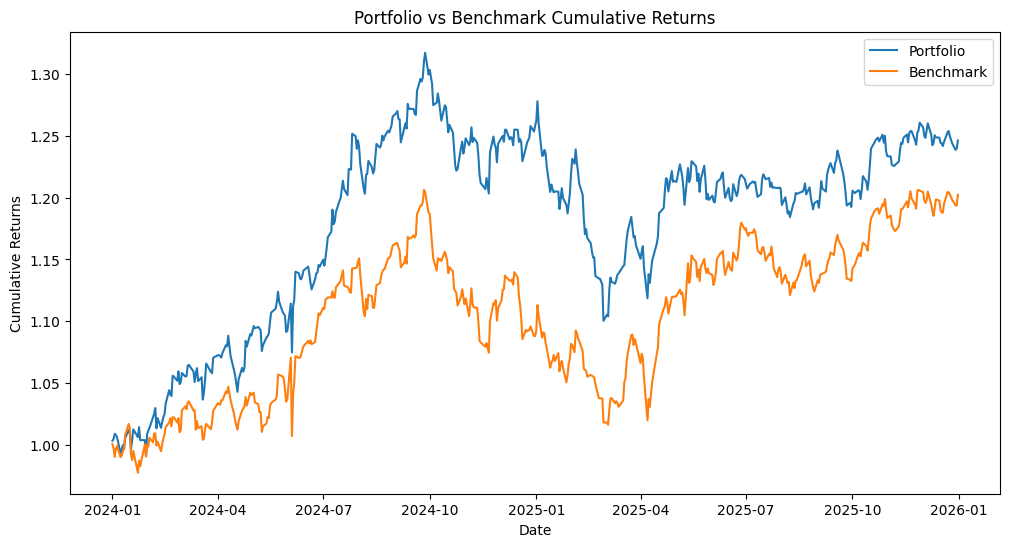

In [213]:
# Portfolio vs Benchmark Cumulative Returns Plot

plt.figure(figsize=(12, 6))
plt.plot(cumulative_portfolio_returns, label='Portfolio')
plt.plot(cumulative_benchmark_returns, label='Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Portfolio vs Benchmark Cumulative Returns')
plt.legend()
plt.show()

| **Key Aspect**         | **Interpretation**                                                                                                                                        |
| ---------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Portfolio Return**   | Portfolio generated a cumulative return of 25%, increasing from 1.00 to 1.25.                                                                   |
| **Benchmark Return**   | Nifty 50 generated a cumulative return of 20.24%, increasing from 1.00 to 1.20.                                                                 |
| **Outperformance**     | The portfolio outperformed the benchmark by approximately 5 percentage points.                                                                        |
| **Maximum Decline**    | The portfolio experienced a significant decline during **Feb–Apr 2025**, falling from around 1.24 to 1.10.                                            |
| **Recovery**           | The portfolio recovered strongly after April 2025 and reached around 1.25 by the end of 2025.                                                         |
| **Overall Conclusion** | The portfolio delivered higher returns than the benchmark, but its fluctuations indicate that risk-adjusted performance should also be evaluated. |



In [214]:
# Key performance metrics for the portfolio and benchmark during the test period
portfolio_cumulative_return = cumulative_portfolio_returns.iloc[-1] - 1
benchmark_cumulative_return = cumulative_benchmark_returns.iloc[-1] - 1

print(f"Portfolio cumulative return during test period: {portfolio_cumulative_return*100:.2f}%")
print(f"Benchmark cumulative return during test period: {benchmark_cumulative_return*100:.2f}%")



Portfolio cumulative return during test period: 24.63%
Benchmark cumulative return during test period: 20.24%


In [215]:
pd.DataFrame({
    "Optimized Portfolio": [portfolio_cumulative_return],
    "Benchmark (Nifty 50)": [benchmark_cumulative_return]
}).to_sql("backtest_results", conn, if_exists="replace")
conn.commit()
print("Backtest results saved to database")

Backtest results saved to database


In [216]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                name
0  optimal_portfolio
1       daily_prices
2         stock_meta
3      stock_summary
4   backtest_results


## Exporting data to Power BI



In [219]:
import os
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\saisu\Desktop\Project\portfolio.db")

# Create data folder
os.makedirs("data", exist_ok=True)

# Export tables
pd.read_sql("SELECT * FROM daily_prices", conn).to_csv("data/daily_prices.csv", index=False)
pd.read_sql("SELECT * FROM stock_meta", conn).to_csv("data/stock_meta.csv", index=False)
pd.read_sql("SELECT * FROM stock_summary", conn).to_csv("data/stock_summary.csv", index=False)
pd.read_sql("SELECT * FROM optimal_portfolio", conn).to_csv("data/optimal_portfolio.csv", index=False)
pd.read_sql("SELECT * FROM backtest_results", conn).to_csv("data/backtest_results.csv", index=False)

print("All tables exported to CSV")

All tables exported to CSV
